# Multi-Shifted Dictionary for Field Map Compensation

This notebook tests the Multi-Shifted Dictionary approach (Approach 0) for field map compensation in GASP.

**Concept:** Generate signal models at multiple discrete field map offsets, then select/interpolate the correct coefficients per-voxel based on the measured field map.

## Approach Overview

1. Train GASP coefficients at discrete field map offset values
2. At inference time, use the measured field map to select/interpolate coefficients per-voxel
3. Apply the appropriate coefficients to each voxel

In [1]:
import sys
from pathlib import Path

# Add project root to path (notebook is in gasp/fieldmap/)
project_root = Path(__file__).parent.parent.parent if '__file__' in dir() else Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# GASP imports
from gasp import ssfp, tissue, responses
from gasp.gasp import train_gasp, run_gasp
from gasp.fieldmap import FieldMapDictionary, train_fieldmap_dictionary, apply_gasp_with_fieldmap

# Set up plotting defaults
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['image.cmap'] = 'gray'

## 1. Setup Simulation Parameters

In [2]:
# Image dimensions
width = 256
height = 256

# Acquisition parameters
TR = 5e-3  # 5ms repetition time
TE = TR / 2  # Echo time at TR/2
alpha = np.deg2rad(60)  # 60 degree flip angle

# Phase cycling - 8 phase cycles evenly spaced
n_pcs = 8
pcs = np.linspace(0, 2 * np.pi, n_pcs, endpoint=False)

print(f"TR = {TR*1e3:.1f} ms")
print(f"TE = {TE*1e3:.1f} ms")
print(f"Flip angle = {np.rad2deg(alpha):.0f} degrees")
print(f"Phase cycles = {n_pcs}")
print(f"Phase cycling values (deg): {np.rad2deg(pcs)}")

TR = 5.0 ms
TE = 2.5 ms
Flip angle = 60 degrees
Phase cycles = 8
Phase cycling values (deg): [  0.  45.  90. 135. 180. 225. 270. 315.]


## 2. Create Tissue Phantom

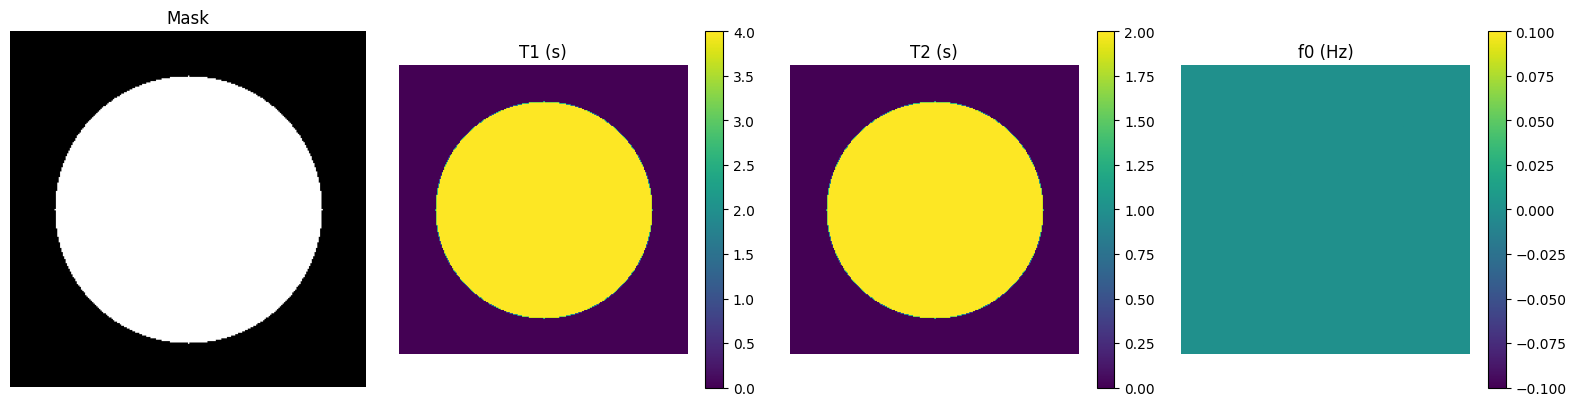

In [3]:
# Generate tissue phantom
t = tissue.tissue_generator(fov=width, type='circle', padding=8)

mask = t['mask']
T1 = t['t1']
T2 = t['t2']
f0_tissue = t['f0']  # Chemical shift from tissue (e.g., fat)

# Flip angle map (uniform in this case)
alpha_map = np.ones((height, width)) * alpha

# Display the phantom
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Mask')

im1 = axes[1].imshow(T1, cmap='viridis')
axes[1].set_title('T1 (s)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(T2, cmap='viridis')
axes[2].set_title('T2 (s)')
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(f0_tissue, cmap='viridis')
axes[3].set_title('f0 (Hz)')
plt.colorbar(im3, ax=axes[3])

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Create a Spatially Varying Field Map

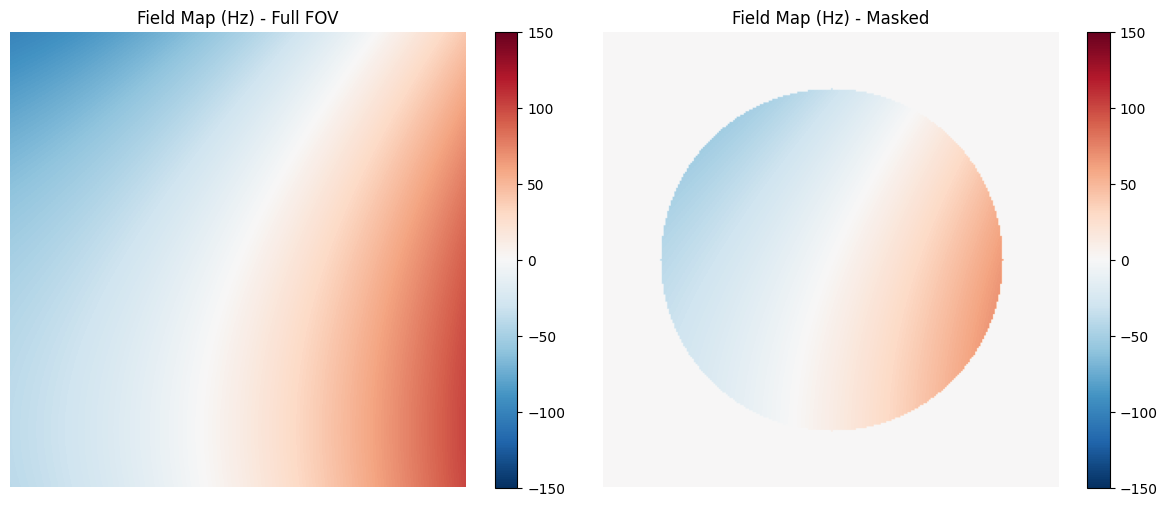

Field map range: -100.0 to 101.2 Hz


In [4]:
# Create a spatially varying field map
# This simulates realistic B0 inhomogeneity

# Linear gradient field map (simulating a global off-resonance gradient)
x = np.linspace(-1, 1, width)
y = np.linspace(-1, 1, height)
X, Y = np.meshgrid(x, y)

# Field map: linear gradient + quadratic curvature
# Range approximately -100 to +100 Hz
field_map_range = 100  # Hz
field_map = field_map_range * (0.7 * X + 0.3 * Y + 0.2 * (X**2 - Y**2))

# Apply mask to field map for visualization
field_map_masked = field_map * mask

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(field_map, cmap='RdBu_r', vmin=-150, vmax=150)
axes[0].set_title('Field Map (Hz) - Full FOV')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(field_map_masked, cmap='RdBu_r', vmin=-150, vmax=150)
axes[1].set_title('Field Map (Hz) - Masked')
plt.colorbar(im1, ax=axes[1])

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Field map range: {field_map.min():.1f} to {field_map.max():.1f} Hz")

## 4. Define Desired Spectral Profile

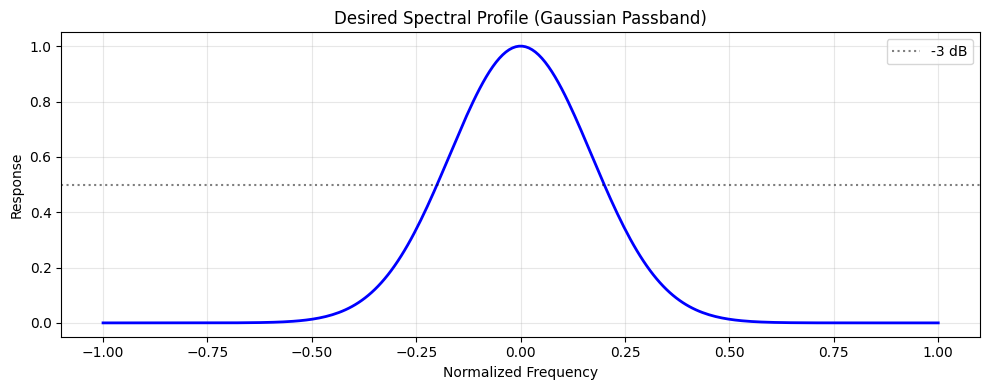

In [5]:
# Create a Gaussian passband filter centered at water frequency
D = responses.gaussian(width, bw=0.2, shift=0)

# Normalize
D = D / D.max()

# Plot the desired response
fig, ax = plt.subplots(figsize=(10, 4))
freq = np.linspace(-1, 1, width)  # Normalized frequency
ax.plot(freq, D, 'b-', linewidth=2)
ax.set_xlabel('Normalized Frequency')
ax.set_ylabel('Response')
ax.set_title('Desired Spectral Profile (Gaussian Passband)')
ax.grid(True, alpha=0.3)
ax.axhline(0.5, color='k', linestyle=':', alpha=0.5, label='-3 dB')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Simulate SSFP Data WITH Field Map

Simulated data shape: (256, 256, 8)


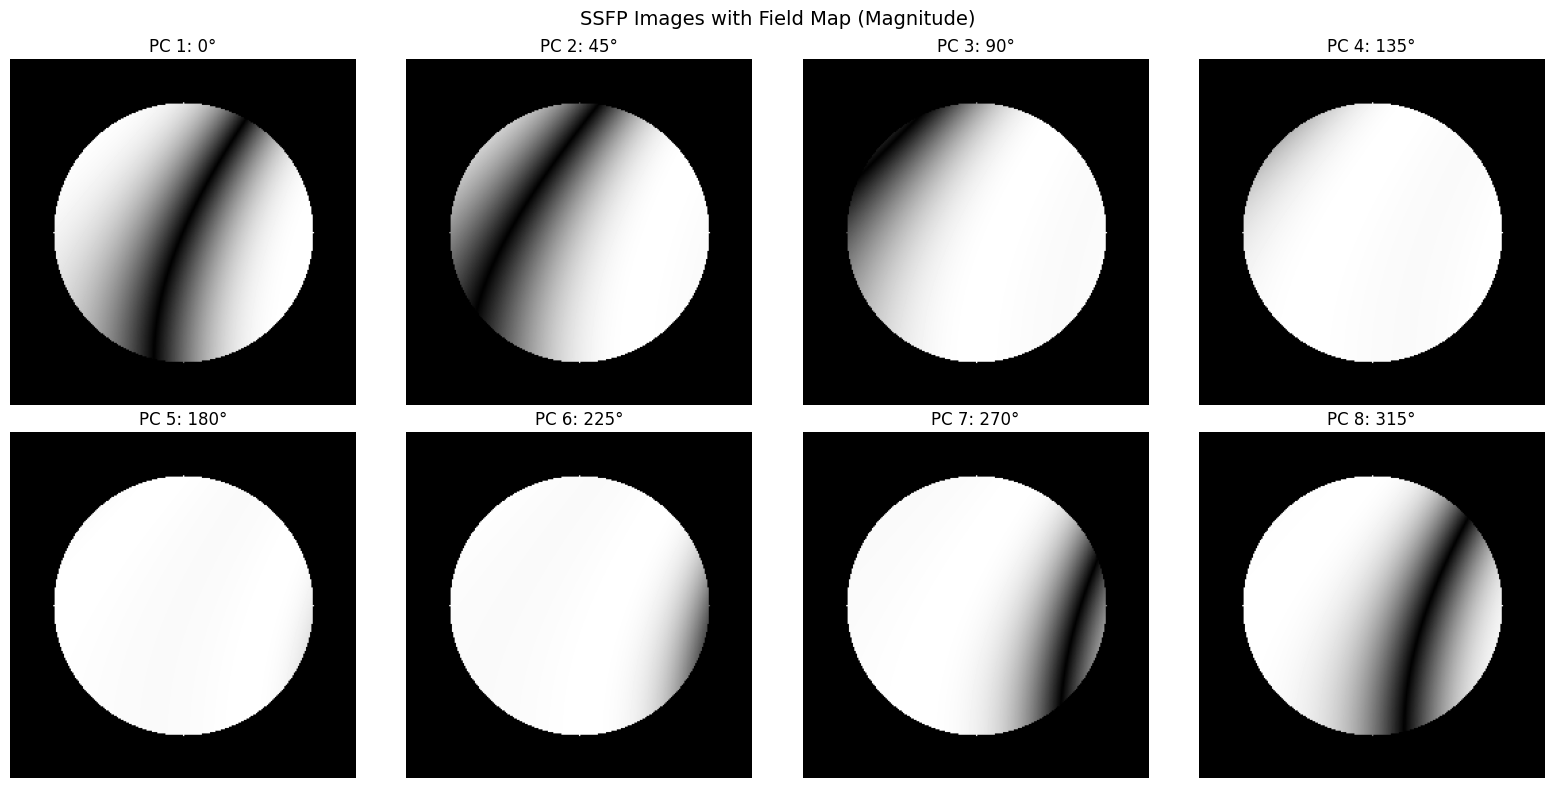

In [6]:
# Simulate SSFP data with the spatially varying field map
# This represents the "acquired" data

M_with_fieldmap = ssfp.ssfp(
    T1, T2, TR, TE, alpha_map,
    dphi=pcs,
    field_map=field_map,
    M0=mask,
    f0=f0_tissue
)

print(f"Simulated data shape: {M_with_fieldmap.shape}")

# Display magnitude images for a few phase cycles
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < n_pcs:
        ax.imshow(np.abs(M_with_fieldmap[:, :, i]), cmap='gray')
        ax.set_title(f'PC {i+1}: {np.rad2deg(pcs[i]):.0f}°')
        ax.axis('off')
plt.suptitle('SSFP Images with Field Map (Magnitude)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Standard GASP (No Field Map Compensation)

First, let's see what happens when we apply standard GASP without accounting for the field map.

In [7]:
# Train standard GASP on the data (ignoring field map effects)
gasp_standard, A_standard = train_gasp(
    M_with_fieldmap, D,
    method='affine',
    useL2=True,
    lam=1e-3
)

print(f"Standard GASP output shape: {gasp_standard.shape}")
print(f"Coefficient shape: {A_standard.shape}")

Standard GASP output shape: (256, 256)
Coefficient shape: (9,)


## 7. Train Multi-Shifted Dictionary

In [8]:
# Define field map offset range for the dictionary
# Should cover the range of field map values in the data
field_range = (-150, 150)  # Hz
n_bins = 31  # Number of dictionary entries

print(f"Training dictionary with {n_bins} bins from {field_range[0]} to {field_range[1]} Hz")

# Train the field map dictionary
fm_dictionary = train_fieldmap_dictionary(
    T1=T1,
    T2=T2,
    TR=TR,
    TE=TE,
    alpha=alpha_map,
    pcs=pcs,
    D=D,
    field_range=field_range,
    n_bins=n_bins,
    method='affine',
    useL2=True,
    lam=1e-3,
    f0=0,  # Base f0 (tissue f0 is already in the simulation)
    M0=mask
)

print(f"Dictionary trained with {len(fm_dictionary.coefficients)} entries")
print(f"Field offsets: {fm_dictionary.field_offsets}")

Training dictionary with 31 bins from -150 to 150 Hz
Dictionary trained with 31 entries
Field offsets: [-150. -140. -130. -120. -110. -100.  -90.  -80.  -70.  -60.  -50.  -40.
  -30.  -20.  -10.    0.   10.   20.   30.   40.   50.   60.   70.   80.
   90.  100.  110.  120.  130.  140.  150.]


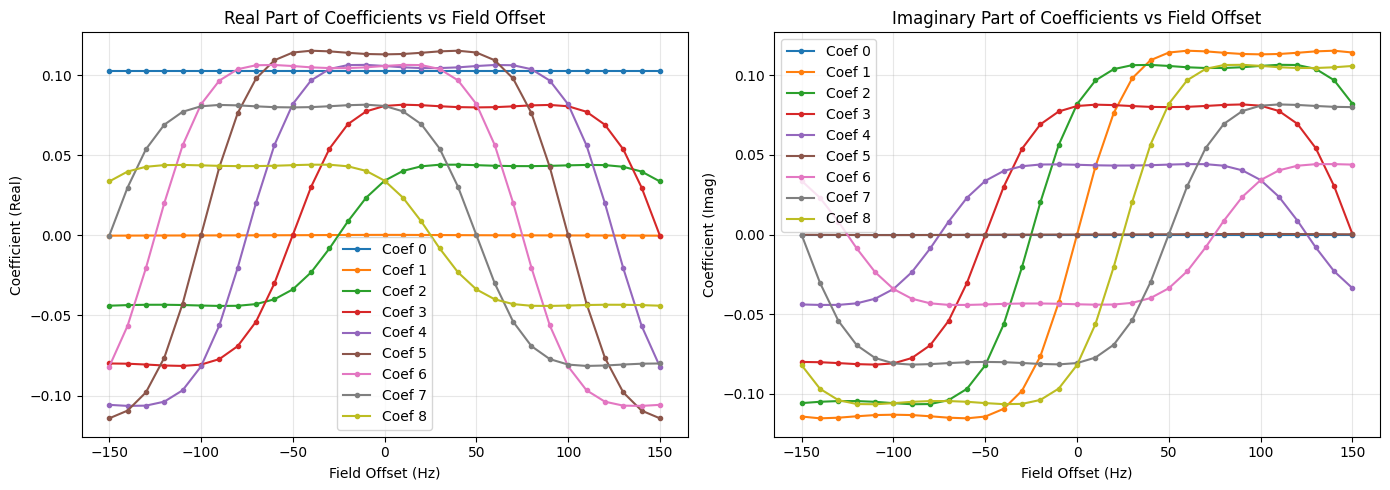

In [9]:
# Visualize how coefficients vary with field map offset
field_offsets = fm_dictionary.field_offsets
coefficients = np.array([fm_dictionary.coefficients[f] for f in field_offsets])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts of coefficients
for i in range(coefficients.shape[1]):
    axes[0].plot(field_offsets, np.real(coefficients[:, i]), '-o', label=f'Coef {i}', markersize=3)
axes[0].set_xlabel('Field Offset (Hz)')
axes[0].set_ylabel('Coefficient (Real)')
axes[0].set_title('Real Part of Coefficients vs Field Offset')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot imaginary parts of coefficients
for i in range(coefficients.shape[1]):
    axes[1].plot(field_offsets, np.imag(coefficients[:, i]), '-o', label=f'Coef {i}', markersize=3)
axes[1].set_xlabel('Field Offset (Hz)')
axes[1].set_ylabel('Coefficient (Imag)')
axes[1].set_title('Imaginary Part of Coefficients vs Field Offset')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Apply Field Map Compensated GASP

In [10]:
# Apply GASP with field map compensation using linear interpolation
gasp_compensated_linear = apply_gasp_with_fieldmap(
    M_with_fieldmap,
    field_map,
    fm_dictionary,
    interpolation='linear',
    vectorized=True
)

# Apply GASP with field map compensation using nearest neighbor
gasp_compensated_nearest = apply_gasp_with_fieldmap(
    M_with_fieldmap,
    field_map,
    fm_dictionary,
    interpolation='nearest',
    vectorized=True
)

print(f"Compensated GASP output shape: {gasp_compensated_linear.shape}")

Compensated GASP output shape: (256, 256)


## 9. Compare Results

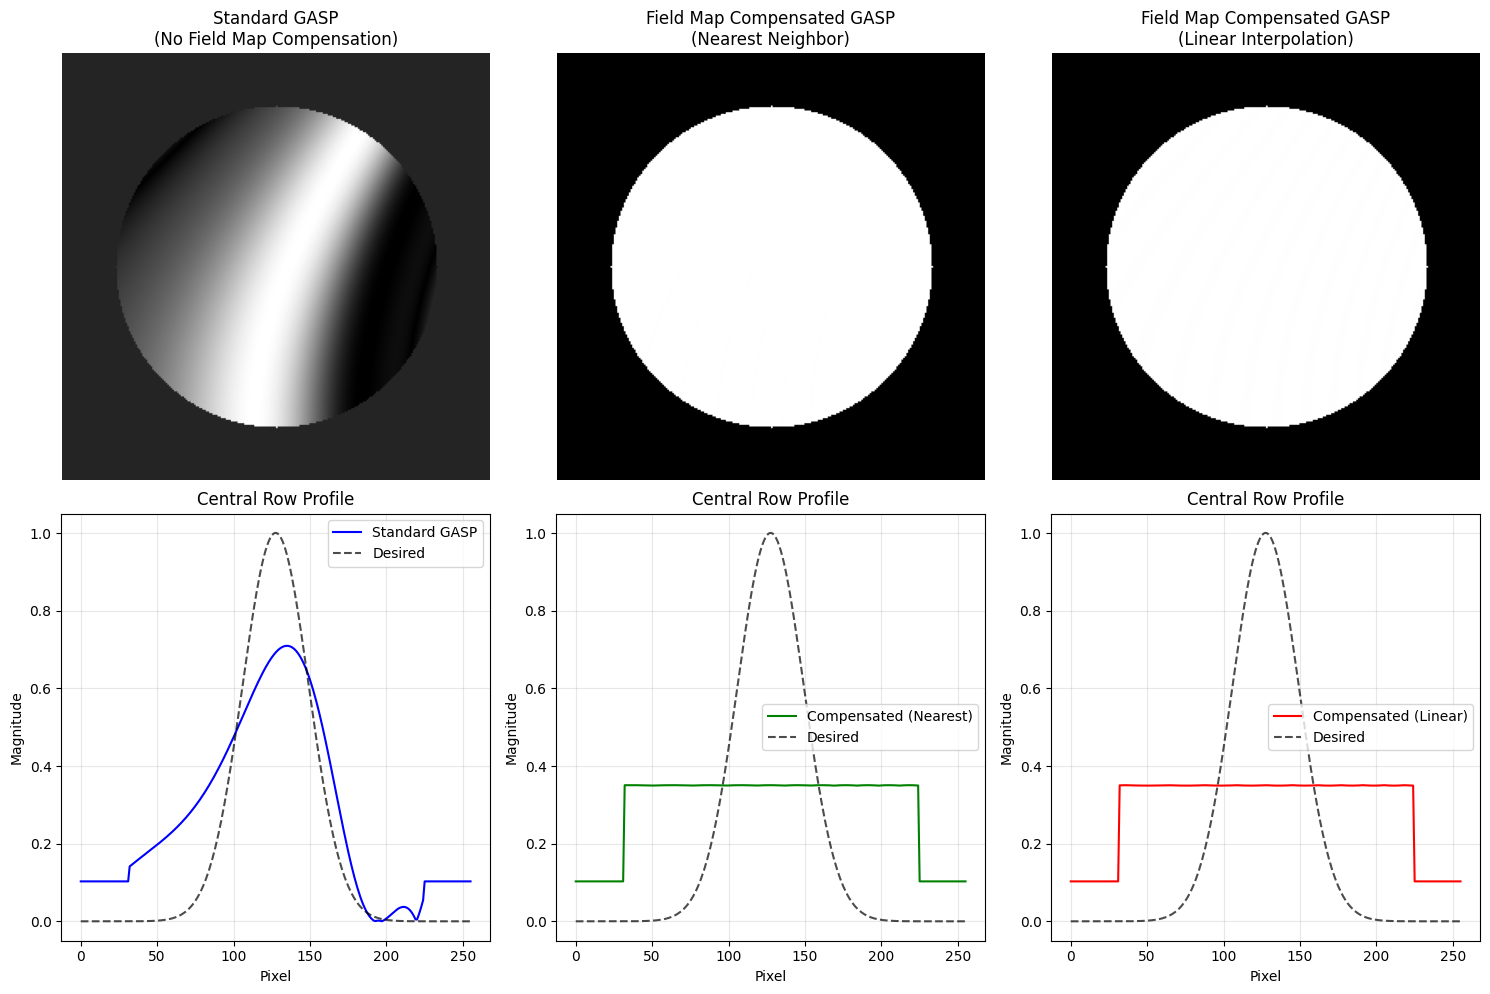

In [11]:
# Create comparison figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: Images
axes[0, 0].imshow(np.abs(gasp_standard), cmap='gray')
axes[0, 0].set_title('Standard GASP\n(No Field Map Compensation)')

axes[0, 1].imshow(np.abs(gasp_compensated_nearest), cmap='gray')
axes[0, 1].set_title('Field Map Compensated GASP\n(Nearest Neighbor)')

axes[0, 2].imshow(np.abs(gasp_compensated_linear), cmap='gray')
axes[0, 2].set_title('Field Map Compensated GASP\n(Linear Interpolation)')

# Bottom row: Profiles through center
center_row = height // 2
x_axis = np.arange(width)

axes[1, 0].plot(x_axis, np.abs(gasp_standard[center_row, :]), 'b-', label='Standard GASP')
axes[1, 0].plot(x_axis, D, 'k--', label='Desired', alpha=0.7)
axes[1, 0].set_xlabel('Pixel')
axes[1, 0].set_ylabel('Magnitude')
axes[1, 0].set_title('Central Row Profile')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(x_axis, np.abs(gasp_compensated_nearest[center_row, :]), 'g-', label='Compensated (Nearest)')
axes[1, 1].plot(x_axis, D, 'k--', label='Desired', alpha=0.7)
axes[1, 1].set_xlabel('Pixel')
axes[1, 1].set_ylabel('Magnitude')
axes[1, 1].set_title('Central Row Profile')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(x_axis, np.abs(gasp_compensated_linear[center_row, :]), 'r-', label='Compensated (Linear)')
axes[1, 2].plot(x_axis, D, 'k--', label='Desired', alpha=0.7)
axes[1, 2].set_xlabel('Pixel')
axes[1, 2].set_ylabel('Magnitude')
axes[1, 2].set_title('Central Row Profile')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

for ax in axes[0, :]:
    ax.axis('off')

plt.tight_layout()
plt.show()

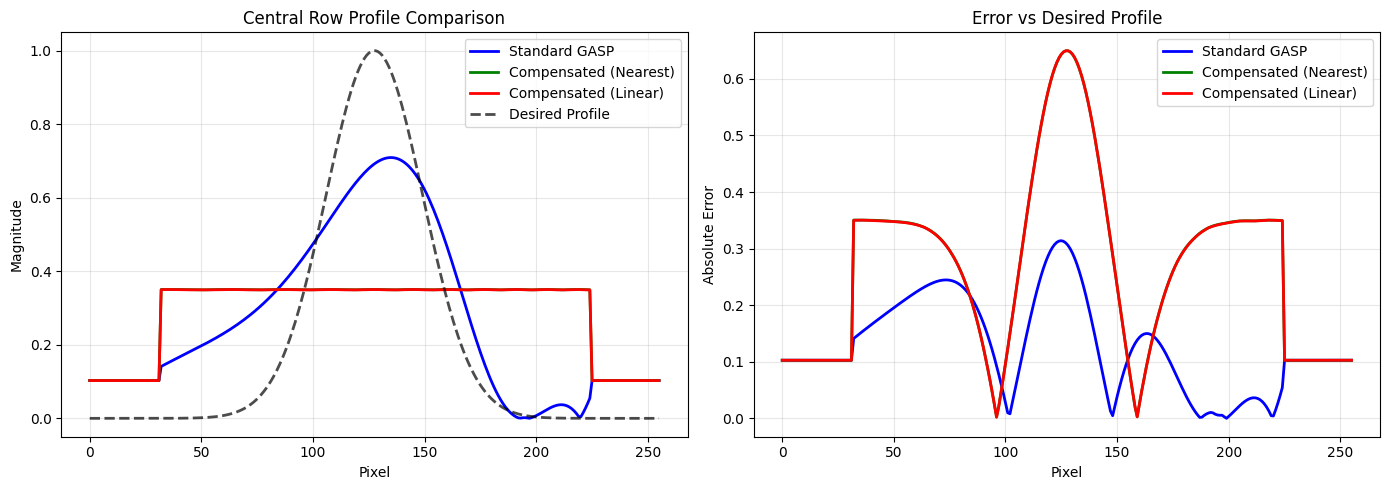

In [12]:
# Overlay comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All profiles on one plot
axes[0].plot(x_axis, np.abs(gasp_standard[center_row, :]), 'b-', label='Standard GASP', linewidth=2)
axes[0].plot(x_axis, np.abs(gasp_compensated_nearest[center_row, :]), 'g-', label='Compensated (Nearest)', linewidth=2)
axes[0].plot(x_axis, np.abs(gasp_compensated_linear[center_row, :]), 'r-', label='Compensated (Linear)', linewidth=2)
axes[0].plot(x_axis, D, 'k--', label='Desired Profile', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Pixel')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('Central Row Profile Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error comparison
error_standard = np.abs(np.abs(gasp_standard[center_row, :]) - D)
error_nearest = np.abs(np.abs(gasp_compensated_nearest[center_row, :]) - D)
error_linear = np.abs(np.abs(gasp_compensated_linear[center_row, :]) - D)

axes[1].plot(x_axis, error_standard, 'b-', label='Standard GASP', linewidth=2)
axes[1].plot(x_axis, error_nearest, 'g-', label='Compensated (Nearest)', linewidth=2)
axes[1].plot(x_axis, error_linear, 'r-', label='Compensated (Linear)', linewidth=2)
axes[1].set_xlabel('Pixel')
axes[1].set_ylabel('Absolute Error')
axes[1].set_title('Error vs Desired Profile')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Quantitative Comparison

In [13]:
# Compute error metrics (within mask only)
def compute_metrics(reconstruction, desired, mask):
    """Compute error metrics within masked region."""
    recon_mag = np.abs(reconstruction)
    
    # Normalize to match desired profile scale
    scale = np.mean(recon_mag[mask.astype(bool)]) / np.mean(desired[mask.astype(bool)])
    recon_normalized = recon_mag / scale
    
    # Compute errors within mask
    mask_bool = mask.astype(bool)
    error = np.abs(recon_normalized - desired)
    
    mse = np.mean(error[mask_bool]**2)
    rmse = np.sqrt(mse)
    mae = np.mean(error[mask_bool])
    max_error = np.max(error[mask_bool])
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'Max Error': max_error}

# Tile desired profile to 2D
D_2d = np.tile(D, (height, 1))

metrics_standard = compute_metrics(gasp_standard, D_2d, mask)
metrics_nearest = compute_metrics(gasp_compensated_nearest, D_2d, mask)
metrics_linear = compute_metrics(gasp_compensated_linear, D_2d, mask)

print("Error Metrics (within mask):")
print("=" * 50)
print(f"{'Metric':<15} {'Standard':<12} {'Nearest':<12} {'Linear':<12}")
print("-" * 50)
for metric in ['MSE', 'RMSE', 'MAE', 'Max Error']:
    print(f"{metric:<15} {metrics_standard[metric]:<12.6f} {metrics_nearest[metric]:<12.6f} {metrics_linear[metric]:<12.6f}")
print("=" * 50)

Error Metrics (within mask):
Metric          Standard     Nearest      Linear      
--------------------------------------------------
MSE             0.071207     0.128444     0.128444    
RMSE            0.266846     0.358391     0.358391    
MAE             0.208957     0.319135     0.319136    
Max Error       0.793006     0.650212     0.649863    


## 11. Effect of Dictionary Resolution

In [14]:
# Test different numbers of dictionary bins
bin_counts = [5, 11, 21, 41, 81]
results = {}

for n_bins in bin_counts:
    print(f"Training dictionary with {n_bins} bins...")
    
    fm_dict = train_fieldmap_dictionary(
        T1=T1, T2=T2, TR=TR, TE=TE,
        alpha=alpha_map, pcs=pcs, D=D,
        field_range=field_range,
        n_bins=n_bins,
        method='affine',
        useL2=True,
        lam=1e-3,
        M0=mask
    )
    
    # Apply with linear interpolation
    gasp_result = apply_gasp_with_fieldmap(
        M_with_fieldmap, field_map, fm_dict,
        interpolation='linear', vectorized=True
    )
    
    metrics = compute_metrics(gasp_result, D_2d, mask)
    results[n_bins] = metrics

print("\nDone!")

Training dictionary with 5 bins...
Training dictionary with 11 bins...
Training dictionary with 21 bins...
Training dictionary with 41 bins...
Training dictionary with 81 bins...

Done!


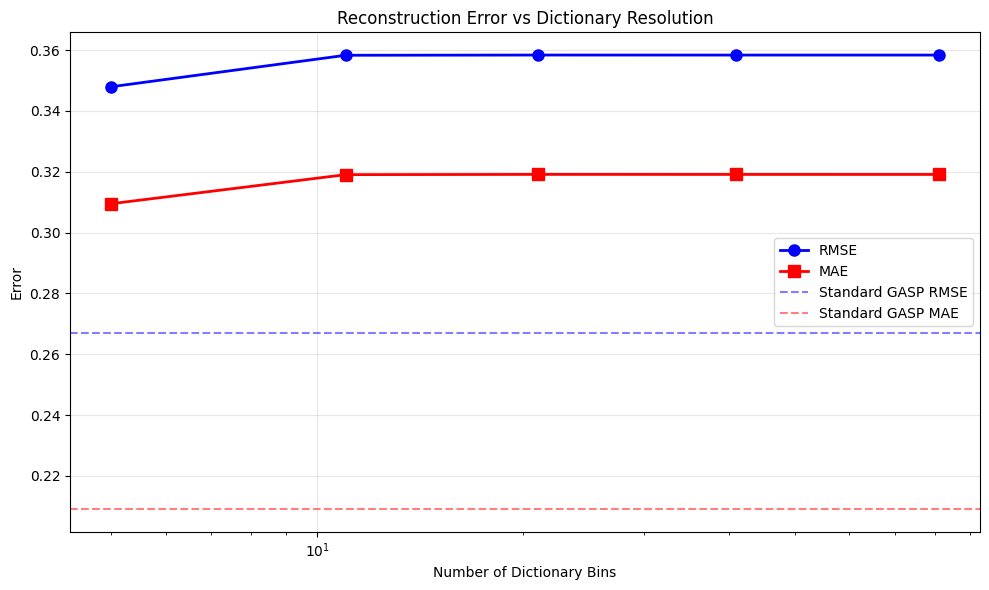


Error vs Number of Bins:
Bins       RMSE            MAE            
----------------------------------------
5          0.347981        0.309510       
11         0.358325        0.319064       
21         0.358397        0.319144       
41         0.358389        0.319132       
81         0.358390        0.319130       


In [15]:
# Plot error vs number of bins
fig, ax = plt.subplots(figsize=(10, 6))

rmse_values = [results[n]['RMSE'] for n in bin_counts]
mae_values = [results[n]['MAE'] for n in bin_counts]

ax.plot(bin_counts, rmse_values, 'bo-', linewidth=2, markersize=8, label='RMSE')
ax.plot(bin_counts, mae_values, 'rs-', linewidth=2, markersize=8, label='MAE')

# Add horizontal line for standard GASP
ax.axhline(metrics_standard['RMSE'], color='b', linestyle='--', alpha=0.5, label='Standard GASP RMSE')
ax.axhline(metrics_standard['MAE'], color='r', linestyle='--', alpha=0.5, label='Standard GASP MAE')

ax.set_xlabel('Number of Dictionary Bins')
ax.set_ylabel('Error')
ax.set_title('Reconstruction Error vs Dictionary Resolution')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.show()

# Print table
print("\nError vs Number of Bins:")
print("=" * 40)
print(f"{'Bins':<10} {'RMSE':<15} {'MAE':<15}")
print("-" * 40)
for n in bin_counts:
    print(f"{n:<10} {results[n]['RMSE']:<15.6f} {results[n]['MAE']:<15.6f}")

## 12. Save and Load Dictionary

In [16]:
# Demonstrate save/load functionality
save_path = '/tmp/fieldmap_dictionary.npz'

# Save
fm_dictionary.save(save_path)
print(f"Dictionary saved to: {save_path}")

# Load
loaded_dictionary = FieldMapDictionary.load(save_path)
print(f"Dictionary loaded with {len(loaded_dictionary.coefficients)} entries")

# Verify they produce the same results
gasp_from_loaded = apply_gasp_with_fieldmap(
    M_with_fieldmap, field_map, loaded_dictionary,
    interpolation='linear', vectorized=True
)

difference = np.abs(gasp_compensated_linear - gasp_from_loaded)
print(f"Max difference after save/load: {difference.max():.2e}")

Dictionary saved to: /tmp/fieldmap_dictionary.npz
Dictionary loaded with 31 entries
Max difference after save/load: 0.00e+00


## 13. Conclusions

This notebook demonstrated the Multi-Shifted Dictionary approach (Approach 0) for field map compensation in GASP.

### Key Findings:

1. **Field map compensation improves reconstruction accuracy** when there is spatially varying off-resonance.

2. **Linear interpolation generally outperforms nearest-neighbor** selection, especially with fewer dictionary bins.

3. **Dictionary resolution matters** - more bins generally give better results, but with diminishing returns.

### Pros:
- Conceptually simple
- Works with existing GASP framework
- No modification to core algorithm
- Dictionary can be pre-computed and saved

### Cons:
- Discrete bins may cause banding artifacts (mitigated by interpolation)
- Memory overhead for storing multiple coefficient sets
- Per-voxel computation can be slow (mitigated by vectorized implementation)